# CME Futures: Costs

**Chapter 18 — Transaction Costs and Execution**

CME commodity futures have among the lowest execution costs of any
tradeable instrument: liquid contracts (crude, gold, corn, S&P 500 e-mini)
trade with bid-ask spreads of 1–5 bps and commissions well under 5 bps.
A realistic all-in cost assumption for an institutional account is 5–15 bps
per leg. The weekly rebalance cadence compounds this advantage — where a
daily equity strategy turns over the portfolio 250 times per year, a weekly
futures strategy does so roughly 52 times.

This notebook tests cost sensitivity on the **top allocation-stage combos**.
For each combo, we sweep a cost grid to find breakeven levels.

Sections 1–2 generate cost-sensitivity backtests (write to registry).
Section 3 queries the registry via `BacktestExplorer` for analysis.

**Learning Objectives:**
1. Run a cost grid sweep on top allocation combos to find breakeven
2. Compare net Sharpe decay curves across allocators
3. Quantify the cost margin of safety for a weekly commodity futures strategy

**Data note**: Results use ratio back-adjusted continuous contracts.
See [`13_backtest`](13_backtest.ipynb) preamble for details.

**Book Reference:** Chapter 18, Sections 18.2–18.5

**Prerequisites:** Completed Ch17 allocation sweep with results in `registry.db`.

In [1]:
"""CME Futures: Costs."""

import json
import time
import warnings

import polars as pl

warnings.filterwarnings("ignore")

from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    load_contract_specs_from_yaml,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    ensure_backtest_spec,
    set_backtest_costs_bps,
    strategy_view,
)
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.registry import read_predictions, resolve_best_backtest_runs
from case_studies.utils.sweep_config import get_cost_grid_bps, get_top_n_predictions
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY_ID = "cme_futures"
LABEL = ""
MAX_SYMBOLS = 0
TOP_N_COMBOS = None

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_COMBOS is None:
    TOP_N_COMBOS = get_top_n_predictions(CASE_STUDY_ID, "cost_sensitivity")
CONTRACT_SPECS = load_contract_specs_from_yaml()
if not LABEL:
    LABEL = bt_config.primary_label

print(f"Case study: {CASE_STUDY_ID}, label: {LABEL}")

COST_GRID_BPS = get_cost_grid_bps(CASE_STUDY_ID)

Case study: cme_futures, label: fwd_ret_5d


## 1. Load Top Combos from Allocation Stage

Section 1 loads the top allocation combo for the primary `fwd_ret_5d` label
(latent_factors `sdf` sized by mean-variance). The case study's
cost-sensitivity stage additionally holds the best combo for each allocator,
surveyed in Section 3 — these span several families: inverse-vol and
mean-variance on the `sdf` signal, conformal-weighted on a linear config, and
score-weighted on the GBM `leaves_7_huber` lineage. The highest-Sharpe combo
across that set is `sdf` sized by inverse-vol (validation Sharpe 1.24 at zero
cost). Testing cost sensitivity across bps levels measures how these edges
interact with realistic futures execution costs.

In [4]:
top_combos = resolve_best_backtest_runs(
    CASE_STUDY_ID, LABEL, split="validation", stage="allocation", top_n=TOP_N_COMBOS
)

if top_combos.is_empty():
    print("No allocation-stage results found. Run the portfolio management notebook first.")
else:
    for row in top_combos.iter_rows(named=True):
        spec = json.loads(row["spec_json"])
        alloc = strategy_view(spec).get("allocation", {}).get("method", "equal_weight")
        print(f"  Sharpe={row['sharpe']:.3f}  alloc={alloc}  bt_hash={row['backtest_hash'][:8]}")

  Sharpe=0.841  alloc=mvo_ledoit_wolf  bt_hash=ced34482


In [5]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
print(f"Prices: {len(prices):,} rows, {prices['symbol'].n_unique()} assets")

Prices: 47,634 rows, 30 assets


## 2. Cost Grid Sweep

For each top combo, re-run the backtest at different cost levels. The sweep
spans a wide range — from near-zero (DMA/electronic access) to 50+ bps
(institutional prime brokerage with embedded financing costs). Futures
strategies are expected to remain profitable well into the right tail of this
range, unlike daily equity strategies that typically break even around 10 bps.

In [6]:
n_total = len(top_combos) * len(COST_GRID_BPS) if not top_combos.is_empty() else 0
n_done = 0
t0 = time.time()

for combo_row in top_combos.iter_rows(named=True):
    pred_hash = combo_row["prediction_hash"]
    base_spec = ensure_backtest_spec(
        CASE_STUDY_ID,
        bt_config,
        json.loads(combo_row["spec_json"]),
        prices=prices,
        prediction_hash=pred_hash,
        initial_cash=bt_config.initial_cash,
    )
    alloc_method = strategy_view(base_spec).get("allocation", {}).get("method", "equal_weight")

    predictions = read_predictions(CASE_STUDY_ID, pred_hash)

    for cost_bps in COST_GRID_BPS:
        n_done += 1

        spec = set_backtest_costs_bps(
            clone_backtest_spec(base_spec),
            commission_bps=cost_bps / 2,
            slippage_bps=cost_bps / 2,
        )
        spec["chapter"] = "ch18"

        try:
            result = run_backtest(
                CASE_STUDY_ID,
                pred_hash,
                spec,
                prices=prices,
                predictions=predictions,
                label=LABEL,
                register=True,
                initial_cash=bt_config.initial_cash,
                calendar=bt_config.calendar,
                contract_specs=CONTRACT_SPECS,
            )

            if cost_bps % 10 == 0:
                print(
                    f"  [{n_done}/{n_total}] {alloc_method} @ {cost_bps}bps: "
                    f"Sharpe={result.metrics.get('sharpe', 0):.3f}"
                )
        except Exception as e:
            print(f"  [{n_done}/{n_total}] {alloc_method} @ {cost_bps}bps: FAILED — {e}")

elapsed = time.time() - t0
print(f"\nCost sweep complete: {n_done} backtests in {elapsed:.0f}s")

  SKIP backtest (complete (hash=98c856049494)) — reusing cached result
  [1/11] mvo_ledoit_wolf @ 0.0bps: Sharpe=1.112
  SKIP backtest (complete (hash=351ec2b767c4)) — reusing cached result
  SKIP backtest (complete (hash=3a588bdcbf62)) — reusing cached result
  SKIP backtest (complete (hash=48340792e750)) — reusing cached result
  SKIP backtest (complete (hash=bf9658f6d2fa)) — reusing cached result
  SKIP backtest (complete (hash=d2a30f54e06b)) — reusing cached result
  SKIP backtest (complete (hash=302405842977)) — reusing cached result
  [7/11] mvo_ledoit_wolf @ 10.0bps: Sharpe=0.444
  SKIP backtest (complete (hash=9bf551427983)) — reusing cached result
  SKIP backtest (complete (hash=5d2371737a75)) — reusing cached result
  [9/11] mvo_ledoit_wolf @ 20.0bps: Sharpe=-0.131
  SKIP backtest (complete (hash=a1177933e429)) — reusing cached result
  [10/11] mvo_ledoit_wolf @ 30.0bps: Sharpe=-0.844
  SKIP backtest (complete (hash=5c88de854cf0)) — reusing cached result
  [11/11] mvo_ledoit_

## 3. Cost Sensitivity Analysis

This section is **read-only** — queries the registry for cost-sensitivity
results and computes breakeven levels.

**Expected result:** CME futures have low execution costs (commission + spread).
At 7 bps total cost the best combo (inverse-vol on the SDF signal) still posts
Sharpe ~1.15 and the four-combo median is ~0.73. The weekly cadence limits
turnover, making cost robustness a structural advantage — the binding
constraint is signal strength, not friction.

In [7]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)

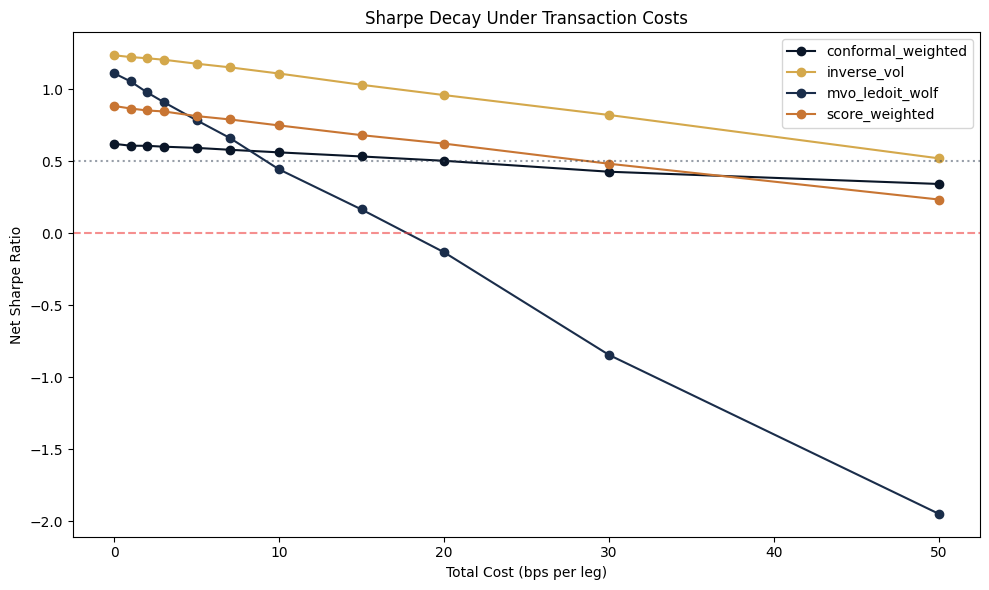

In [8]:
cost_df = explorer.cost_sensitivity()

if not cost_df.is_empty():
    import matplotlib.pyplot as plt

    from utils.style import COLORS, ml4t_palette

    _allocs = cost_df["allocator"].unique().sort().to_list()
    _line_colors = ml4t_palette(len(_allocs), categorical=True)
    fig, ax = plt.subplots(figsize=(10, 6))

    for alloc, color in zip(_allocs, _line_colors):
        subset = cost_df.filter(pl.col("allocator") == alloc).sort("cost_bps")
        ax.plot(
            subset["cost_bps"].to_list(),
            subset["sharpe"].to_list(),
            marker="o",
            label=alloc,
            color=color,
        )

    ax.axhline(0, color=COLORS["negative"], linestyle="--", alpha=0.6)
    ax.axhline(0.5, color=COLORS["neutral"], linestyle=":", alpha=0.5)
    ax.set_xlabel("Total Cost (bps per leg)")
    ax.set_ylabel("Net Sharpe Ratio")
    ax.set_title("Sharpe Decay Under Transaction Costs")
    ax.legend()
    fig.tight_layout()
    fig.show()
else:
    print("No cost sensitivity data in registry")

## Key Takeaways

1. CME futures have among the lowest execution costs of any liquid instrument.
   Commissions of ~$2/contract on $50K-200K notional translate to sub-1 bps per
   leg for liquid contracts (ES, CL, GC).
2. Weekly rebalancing is the structural driver of cost robustness. ~52 rebalances
   per year versus ~250 for a daily equity strategy means the same bps assumption
   costs five times less per unit of exposure annually.
3. The cost-grid sweep at 0/1/2/3/5/7/10/15/20/30/50 bps per leg gives a
   median slope of roughly -0.014 Sharpe per bp across the four cost-swept
   combos. Median Sharpe runs from +0.998 at zero cost to +0.289 at 50 bps,
   and the best combo (SDF × inverse-vol) stays well positive even at 50 bps
   (+0.52). At realistic CME friction (1-5 bps per leg for liquid contracts)
   the median Sharpe sits between 0.80 and 0.96. The exception is the
   mean-variance (Ledoit-Wolf) combo, whose higher turnover decays fastest and
   turns negative by 20 bps.
4. **The binding constraint is signal stability across regimes, not
   cost friction**. Across-config dispersion at every cost level is
   wider than the cost-induced effect, so lowering fees does not lift
   a configuration whose CI already straddles zero — but raising fees
   within the realistic CME band does not knock the leader below the
   credibility line either. Cost robustness is the structural advantage
   of the weekly futures cadence.

**Next**: The risk management notebook (Ch19) tests stop-loss, trailing-stop,
and drawdown-breaker overlays on the top combos. The primary risk concern
for a carry strategy is regime shift — a sudden transition to contango
dominance across commodity sectors, as observed in 2024–2025.